# TP4: K-means

**L'algorithme k-means:**

L'algorithme k-means se déroue en 4 étapes:
1. Choisir k objets formant ainsi k clusters
2. (Ré)affecter chaque objet O au cluster Ci de centre Mi tel que dist(O,Mi) est minimal
3. Recalculer Mi de chaque cluster(le barycentre)
4. Aller à l'étape 2 si on vient de faire une affectation

Library imports

In [81]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

In [82]:
documents = ["This little kitty came to play when I was eating at a restaurant.",
             "Merley has the best squooshy kitten belly.",
             "Google Translate app is incredibe.",
             "If you open 100 tab in google you get a smiley face.",
             "Best cat photo I've ever taken.",
             "Climbing ninja cat.",
             "Impressed with google map feedback.",
             "key promoter extension for Google Chrome.",
             "Google Chrome is the best browser for extensions.",
            "My little cat loves playing with the new app.",
            "I took a photo of my kitten using a Google app."]

Nettoyage de données

In [83]:
vectorizer = TfidfVectorizer(stop_words='english')

Calcul de la matrice de TF-IDF associé à ce corpus

In [84]:
X = vectorizer.fit_transform(documents)

Affichage du vocabulaire

In [85]:
print(vectorizer.vocabulary_)

{'little': 20, 'kitty': 19, 'came': 5, 'play': 28, 'eating': 9, 'restaurant': 31, 'merley': 23, 'best': 3, 'squooshy': 33, 'kitten': 18, 'belly': 2, 'google': 14, 'translate': 37, 'app': 1, 'incredibe': 16, 'open': 26, '100': 0, 'tab': 34, 'smiley': 32, 'face': 12, 'cat': 6, 'photo': 27, 've': 39, 'taken': 35, 'climbing': 8, 'ninja': 25, 'impressed': 15, 'map': 22, 'feedback': 13, 'key': 17, 'promoter': 30, 'extension': 10, 'chrome': 7, 'browser': 4, 'extensions': 11, 'loves': 21, 'playing': 29, 'new': 24, 'took': 36, 'using': 38}


Affichage des attributs

In [86]:
print(vectorizer.get_feature_names_out())

['100' 'app' 'belly' 'best' 'browser' 'came' 'cat' 'chrome' 'climbing'
 'eating' 'extension' 'extensions' 'face' 'feedback' 'google' 'impressed'
 'incredibe' 'key' 'kitten' 'kitty' 'little' 'loves' 'map' 'merley' 'new'
 'ninja' 'open' 'photo' 'play' 'playing' 'promoter' 'restaurant' 'smiley'
 'squooshy' 'tab' 'taken' 'took' 'translate' 'using' 've']


Initialisation du nombre de cluster (la valeur de k=2)

In [87]:
true_k = 2
model = KMeans(n_clusters=true_k, init='k-means++', max_iter=100, n_init=1)
model.fit(X)

KMeans(max_iter=100, n_clusters=2, n_init=1)

Le cluster de chaque document

In [88]:
print(model.labels_)

[0 0 1 1 1 0 1 1 1 0 0]


La prédiction de la classe de document "Chrome browser to open"

In [89]:
print("Prédiction:")
Y = vectorizer.transform(["Chrome browser to open."])
prediction = model.predict(Y)
print(prediction)

Prédiction:
[1]


La prédiction de la classe de document "My cat is hungry"

In [90]:
Y = vectorizer.transform(["My cat is hungry."])
prediction = model.predict(Y)
print(prediction)

[0]


Affichage des attributs qui caractérisent chaque cluster (Catégorie)

In [91]:
print("Top terms per cluster:")
order_centroids = model.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()
for i in range(true_k):
    print("Cluster %d:" % i)
    for ind in order_centroids[i, :10]:
        print(' %s' % terms[ind])
    print()

Top terms per cluster:
Cluster 0:
 kitten
 cat
 little
 app
 climbing
 ninja
 belly
 squooshy
 merley
 took

Cluster 1:
 google
 chrome
 best
 translate
 incredibe
 map
 impressed
 feedback
 extensions
 browser



Refaire le même travail pour k=3, k=4, ...,k=10

Pour k = 3

In [92]:
true_k1 = 3
model1 = KMeans(n_clusters=true_k1, init='k-means++', max_iter=100, n_init=1)
model1.fit(X)

KMeans(max_iter=100, n_clusters=3, n_init=1)

In [93]:
print(model1.labels_)

[0 1 1 1 1 2 1 1 1 2 1]


In [94]:
print("Prédiction:")
Y1 = vectorizer.transform(["Chrome browser to open."])
prediction = model1.predict(Y1)
print(prediction)

Prédiction:
[1]


In [95]:
print("Top terms per cluster:")
order_centroids = model1.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()
for i in range(true_k1):
    print("Cluster %d:" % i)
    for ind in order_centroids[i, :10]:
        print(' %s' % terms[ind])
    print()

Top terms per cluster:
Cluster 0:
 kitty
 eating
 came
 restaurant
 play
 little
 impressed
 google
 feedback
 face

Cluster 1:
 google
 best
 chrome
 photo
 kitten
 app
 incredibe
 translate
 feedback
 impressed

Cluster 2:
 cat
 climbing
 ninja
 loves
 playing
 new
 little
 app
 ve
 extensions



de k = 4 jusqu'à k = 10

In [96]:
with open("output.txt", "w", encoding="utf-8") as f:
    for i in range(3, 11):
        true_k2 = i
        model2 = KMeans(n_clusters=true_k2, init='k-means++', max_iter=100, n_init=1)
        model2.fit(X)
        
        current_order_centroids = model2.cluster_centers_.argsort()[:, ::-1]
        
        print(f"--- Results for k={i} ---", file=f)
        print(f"Labels: {model2.labels_}", file=f)
        
        Y2 = vectorizer.transform(["Chrome browser to open."])
        prediction = model2.predict(Y2)
        print(f"Prédiction for 'Chrome browser to open.': {prediction}", file=f)
        
        for cluster_num in range(true_k2):
            print(f"Cluster {cluster_num}:", file=f)
            for ind in current_order_centroids[cluster_num, :10]:
                print(f" {terms[ind]}", file=f)
        
        print("\n", file=f)

Comment peut-on optimiser la valeur de k?

On peut optimiser la valeur de k soit en utiisant la méthode du coude soit en utilisant le coefficient de silhouette.

Implémentation de la méthode du coude

Nombre de documents dans la matrice X : 11


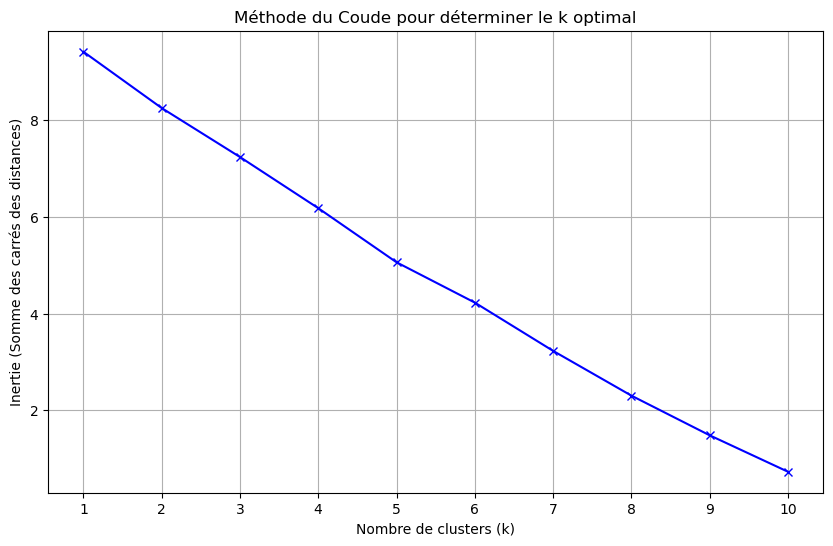

In [97]:
import matplotlib.pyplot as plt

inertias = []
k_range = range(1, 11) # On teste de 1 à 10 clusters
print(f"Nombre de documents dans la matrice X : {X.shape[0]}")
for k in k_range:
    model = KMeans(n_clusters=k, init='k-means++', max_iter=100, n_init=1, random_state=42)
    model.fit(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bx-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie (Somme des carrés des distances)')
plt.title('Méthode du Coude pour déterminer le k optimal')
plt.xticks(k_range)
plt.grid(True)
plt.show()

Implémentation du coefficient de silhouette:

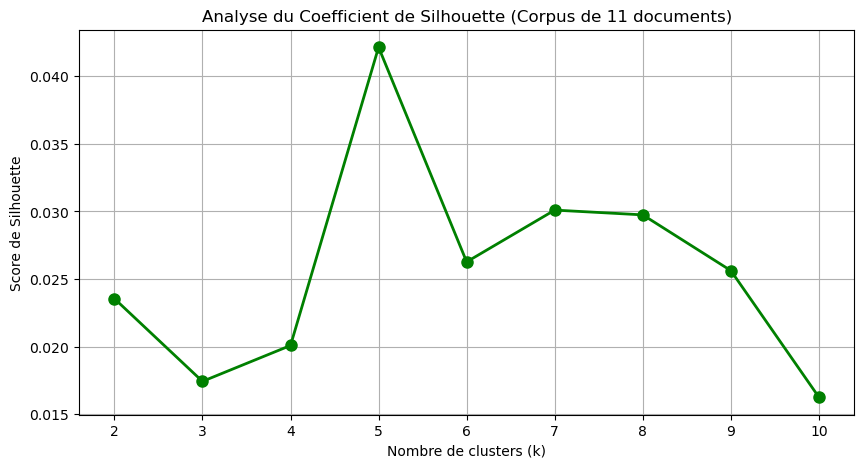

In [98]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range = range(2, 11) 
silhouette_avg = []

for k in k_range:
    model = KMeans(n_clusters=k, init='k-means++', max_iter=100, n_init=1, random_state=42)
    cluster_labels = model.fit_predict(X)
    
    silhouette_avg.append(silhouette_score(X, cluster_labels))

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_avg, 'go-', linewidth=2, markersize=8)
plt.title('Analyse du Coefficient de Silhouette (Corpus de 11 documents)')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score de Silhouette')
plt.grid(True)
plt.show()